In [25]:
# ==========================================
# 1번 셀: 기본 라이브러리 불러오기
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

In [26]:
# ==========================================
# 2번 셀 : 데이터 불러오기 수정버전
# ==========================================

import pandas as pd
import json

# 파일 경로
file_path = "renttherunway_final_data.json"

# 한 줄씩 직접 읽기
data = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except:
            pass   # 깨진 줄은 무시

# DataFrame 변환
df = pd.DataFrame(data)

# 데이터 크기 확인
print("데이터 크기 :", df.shape)

# 컬럼 확인
print("\n컬럼 목록")
print(df.columns)

# 데이터 일부 확인
print("\n데이터 샘플")
display(df.head())

# 기본 정보 확인
print("\n데이터 정보")
print(df.info())

# 결측치 확인
print("\n결측치 개수")
print(df.isnull().sum())

# fit 컬럼 종류 확인
print("\nfit 종류")
print(df['fit'].value_counts())

# rented_for 종류 확인
print("\nrented_for 종류")
print(df['rented for'].value_counts().head(10))

# category 종류 확인
print("\ncategory 종류")
print(df['category'].value_counts().head(10))

데이터 크기 : (192544, 15)

컬럼 목록
Index(['fit', 'user_id', 'bust size', 'item_id', 'weight', 'rating',
       'rented for', 'review_text', 'body type', 'review_summary', 'category',
       'height', 'size', 'age', 'review_date'],
      dtype='object')

데이터 샘플


,fit,user_id,bust size,item_id,weight,rating,rented for,review_text,body type,review_summary,category,height,size,age,review_date
0,fit,420272,34d,2260466,137lbs,10,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,"5' 8""",14,28,"April 20, 2016"
1,fit,273551,34b,153475,132lbs,10,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,"5' 6""",12,36,"June 18, 2013"
2,fit,360448,NaN,1063761,NaN,10,party,This hugged in all the right places! It was a ...,NaN,It was a great time to celebrate the (almost) ...,sheath,"5' 4""",4,116,"December 14, 2015"
3,fit,909926,34c,126335,135lbs,8,formal affair,I rented this for my company's black tie award...,pear,Dress arrived on time and in perfect condition.,dress,"5' 5""",8,34,"February 12, 2014"
4,fit,151944,34b,616682,145lbs,10,wedding,I have always been petite in my upper body and...,athletic,Was in love with this dress !!!,gown,"5' 9""",12,27,"September 26, 2016"



데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192544 entries, 0 to 192543
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   fit             192544 non-null  object
 1   user_id         192544 non-null  object
 2   bust size       174133 non-null  object
 3   item_id         192544 non-null  object
 4   weight          162562 non-null  object
 5   rating          192462 non-null  object
 6   rented for      192534 non-null  object
 7   review_text     192544 non-null  object
 8   body type       177907 non-null  object
 9   review_summary  192544 non-null  object
 10  category        192544 non-null  object
 11  height          191867 non-null  object
 12  size            192544 non-null  int64 
 13  age             191584 non-null  object
 14  review_date     192544 non-null  object
dtypes: int64(1), object(14)
memory usage: 22.0+ MB
None

결측치 개수
fit                   0
user_id               0
bus

In [27]:
# ==========================================
# 3번 셀 : 컬럼명 정리 + 예측 변수 생성
# ==========================================

# 원본 보존
df_original = df.copy()

# 컬럼명 정리
# 공백을 _로 바꾸고 전부 소문자로 통일
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("정리된 컬럼명")
print(df.columns)

# fit 컬럼 확인
print("\nfit 값 분포")
print(df["fit"].value_counts())

# fit_feedback 생성
# fit이면 만족(1), small/large이면 불만족(0)
df["fit_feedback"] = df["fit"].apply(lambda x: 1 if x == "fit" else 0)

print("\nfit_feedback 분포")
print(df["fit_feedback"].value_counts())

print("\nfit_feedback 비율")
print(df["fit_feedback"].value_counts(normalize=True))

# 분석에 사용할 주요 컬럼 확인
main_cols = [
    "fit", "fit_feedback", "user_id", "item_id",
    "bust_size", "body_type", "height", "weight",
    "size", "age", "rating", "rented_for", "category"
]

display(df[main_cols].head())

정리된 컬럼명
Index(['fit', 'user_id', 'bust_size', 'item_id', 'weight', 'rating',
       'rented_for', 'review_text', 'body_type', 'review_summary', 'category',
       'height', 'size', 'age', 'review_date'],
      dtype='object')

fit 값 분포
fit
fit      142058
small     25779
large     24707
Name: count, dtype: int64

fit_feedback 분포
fit_feedback
1    142058
0     50486
Name: count, dtype: int64

fit_feedback 비율
fit_feedback
1    0.737795
0    0.262205
Name: proportion, dtype: float64


,fit,fit_feedback,user_id,item_id,bust_size,body_type,height,weight,size,age,rating,rented_for,category
0,fit,1,420272,2260466,34d,hourglass,"5' 8""",137lbs,14,28,10,vacation,romper
1,fit,1,273551,153475,34b,straight & narrow,"5' 6""",132lbs,12,36,10,other,gown
2,fit,1,360448,1063761,NaN,NaN,"5' 4""",NaN,4,116,10,party,sheath
3,fit,1,909926,126335,34c,pear,"5' 5""",135lbs,8,34,8,formal affair,dress
4,fit,1,151944,616682,34b,athletic,"5' 9""",145lbs,12,27,10,wedding,gown


In [28]:
# ==========================================
# 4번 셀 : 숫자형 전처리 + BMI 생성
# ==========================================

import re

# height 변환 함수
# 예: 5' 8" -> 68 inch
def height_to_inches(height):
    if pd.isnull(height):
        return np.nan

    match = re.match(r"(\d+)'\s*(\d+)", str(height))

    if match:
        feet = int(match.group(1))
        inches = int(match.group(2))
        return feet * 12 + inches

    return np.nan


# weight 변환 함수
# 예: 137lbs -> 137
def weight_to_lbs(weight):
    if pd.isnull(weight):
        return np.nan

    return pd.to_numeric(
        str(weight).replace("lbs", "").strip(),
        errors="coerce"
    )


# 숫자형 변환
df["height_in"] = df["height"].apply(height_to_inches)
df["weight_lbs"] = df["weight"].apply(weight_to_lbs)

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["size"] = pd.to_numeric(df["size"], errors="coerce")

# BMI 계산
# BMI = weight(lbs) / height(in)^2 * 703
df["bmi"] = df["weight_lbs"] / (df["height_in"] ** 2) * 703

# 결과 확인
check_cols = [
    "height", "height_in",
    "weight", "weight_lbs",
    "age", "rating", "size", "bmi"
]

display(df[check_cols].head(10))

print("숫자형 변수 결측치 확인")
print(df[["height_in", "weight_lbs", "age", "rating", "size", "bmi"]].isnull().sum())

print("\nBMI 기초 통계")
display(df["bmi"].describe())

,height,height_in,weight,weight_lbs,age,rating,size,bmi
0,"5' 8""",68.0,137lbs,137.0,28.0,10.0,14,20.828503
1,"5' 6""",66.0,132lbs,132.0,36.0,10.0,12,21.303030
2,"5' 4""",64.0,NaN,NaN,116.0,10.0,4,NaN
3,"5' 5""",65.0,135lbs,135.0,34.0,8.0,8,22.462722
4,"5' 9""",69.0,145lbs,145.0,27.0,10.0,12,21.410418
5,"5' 8""",68.0,138lbs,138.0,45.0,8.0,8,20.980536
6,"5' 3""",63.0,112lbs,112.0,27.0,10.0,4,19.837743
7,"5' 3""",63.0,118lbs,118.0,65.0,10.0,8,20.900479
8,"5' 6""",66.0,NaN,NaN,27.0,10.0,21,NaN
9,"5' 3""",63.0,114lbs,114.0,33.0,10.0,1,20.191988


숫자형 변수 결측치 확인
height_in       677
weight_lbs    29982
age             960
rating           82
size              0
bmi           30426
dtype: int64

BMI 기초 통계


,bmi
count,162118.000000
mean,22.670947
std,3.380015
min,8.069330
25%,20.372405
50%,21.968750
75%,24.126627
max,54.527435


In [29]:
# ==========================================
# 5번 셀 : 이상치 처리
# ==========================================

print("이상치 처리 전 데이터 크기:", df.shape)

# 이상치 처리 기준
# age: 현실적으로 15세 이상 80세 이하만 사용
# height: 48~78 inch 범위 사용
# weight: 80~300 lbs 범위 사용
# BMI: 12~50 범위 사용
# rating: 0~10 범위 사용

df = df[
    (df["age"].between(15, 80)) &
    (df["height_in"].between(48, 78)) &
    (df["weight_lbs"].between(80, 300)) &
    (df["bmi"].between(12, 50)) &
    (df["rating"].between(0, 10)) &
    (df["size"].notnull())
]

print("이상치 처리 후 데이터 크기:", df.shape)

# 처리 후 기초 통계 확인
display(df[["age", "height_in", "weight_lbs", "bmi", "rating", "size"]].describe())

# fit_feedback 분포 재확인
print("\nfit_feedback 분포")
print(df["fit_feedback"].value_counts())

print("\nfit_feedback 비율")
print(df["fit_feedback"].value_counts(normalize=True))

이상치 처리 전 데이터 크기: (192544, 19)
이상치 처리 후 데이터 크기: (161564, 19)


,age,height_in,weight_lbs,bmi,rating,size
count,161564.000000,161564.000000,161564.000000,161564.000000,161564.000000,161564.000000
mean,33.992306,65.272319,137.395812,22.670870,9.090589,11.509229
std,7.942776,2.652689,21.865433,3.372003,1.430714,7.953308
min,15.000000,54.000000,80.000000,14.630593,2.000000,0.000000
25%,29.000000,63.000000,123.000000,20.372405,8.000000,4.000000
50%,32.000000,65.000000,135.000000,22.001050,10.000000,9.000000
75%,37.000000,67.000000,148.000000,24.126627,10.000000,16.000000
max,77.000000,78.000000,300.000000,49.917160,10.000000,58.000000



fit_feedback 분포
fit_feedback
1    118992
0     42572
Name: count, dtype: int64

fit_feedback 비율
fit_feedback
1    0.736501
0    0.263499
Name: proportion, dtype: float64


In [30]:
# ==========================================
# 6번 셀 : bust_size 정리
# ==========================================

import re

# bust_size 예시:
# 34b, 34d+, 32dd, 40ddd/e, 38f 등

def extract_bust_number(bust):
    if pd.isnull(bust):
        return np.nan

    match = re.match(r"(\d+)", str(bust).lower())

    if match:
        return int(match.group(1))

    return np.nan


def extract_bust_cup(bust):
    if pd.isnull(bust):
        return np.nan

    bust = str(bust).lower()

    # 숫자 제거 후 컵 문자만 남김
    cup = re.sub(r"\d+", "", bust)
    cup = cup.replace("+", "")
    cup = cup.replace("/", "_")
    cup = cup.strip()

    if cup == "":
        return np.nan

    return cup


df["bust_size_number"] = df["bust_size"].apply(extract_bust_number)
df["bust_size_cup"] = df["bust_size"].apply(extract_bust_cup)

# 결과 확인
display(df[["bust_size", "bust_size_number", "bust_size_cup"]].head(20))

print("bust_size_number 결측치:")
print(df["bust_size_number"].isnull().sum())

print("\nbust_size_cup 상위 값:")
print(df["bust_size_cup"].value_counts().head(15))

,bust_size,bust_size_number,bust_size_cup
0,34d,34.0,d
1,34b,34.0,b
3,34c,34.0,c
4,34b,34.0,b
5,32b,32.0,b
6,34c,34.0,c
7,34d+,34.0,d
9,32b,32.0,b
10,34b,34.0,b
11,34b,34.0,b


bust_size_number 결측치:
10738

bust_size_cup 상위 값:
bust_size_cup
b        43877
c        43025
d        40878
a        13887
dd        5655
ddd_e     2010
aa         644
g          366
f          321
h          116
i           26
j           21
Name: count, dtype: int64


In [52]:
# ==========================================
# 7번 셀 : 결측치 처리 + 모델용 기본 데이터 생성
# ==========================================

# 사용할 주요 컬럼 선택
use_cols = [
    "fit_feedback",

    # 고객 정보
    "age",
    "height_in",
    "weight_lbs",
    "bmi",
    "body_type",

    # bust 정보
    "bust_size_number",
    "bust_size_cup",

    # 상품 정보
    "item_id",
    "size",
    "category",
    "rating",

    # 상황 정보
    "rented_for"
]

# 필요한 컬럼만 복사
df_model = df[use_cols].copy()

print("초기 데이터 크기:", df_model.shape)

# ------------------------------------------
# 수치형 결측치 처리
# 중앙값으로 채우기
# ------------------------------------------

numeric_cols = [
    "age",
    "height_in",
    "weight_lbs",
    "bmi",
    "bust_size_number",
    "rating",
    "size"
]

for col in numeric_cols:
    median_value = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_value)

# ------------------------------------------
# 범주형 결측치 처리
# Unknown으로 채우기
# ------------------------------------------

categorical_cols = [
    "body_type",
    "bust_size_cup",
    "category",
    "rented_for"
]

for col in categorical_cols:
    df_model[col] = df_model[col].fillna("Unknown")

# ------------------------------------------
# item_id 결측치 처리
# item_id는 상품 기반 feature 생성에 필요하므로 결측치는 제거
# ------------------------------------------

df_model = df_model.dropna(subset=["item_id", "fit_feedback"])

# item_id는 범주형처럼 쓰이지만 groupby에 필요하므로 문자열로 통일
df_model["item_id"] = df_model["item_id"].astype(str)

# target은 정수형으로 변환
df_model["fit_feedback"] = df_model["fit_feedback"].astype(int)

# 결과 확인
print("\n결측치 처리 후 데이터 크기:", df_model.shape)

print("\n결측치 개수")
print(df_model.isnull().sum())

print("\nfit_feedback 분포")
print(df_model["fit_feedback"].value_counts())

print("\nfit_feedback 비율")
print(df_model["fit_feedback"].value_counts(normalize=True))

display(df_model.head())

### BMI 그룹 분석 결과

#Normal BMI 그룹에서 상대적으로 높은 만족도를 보였으며, BMI가 높아질수록 불만족 비율이 증가하는 경향이 나타났다.

#이는 고객 체형과 의류 fit 사이의 관계가 만족도에 영향을 줄 수 있음을 의미한다.

초기 데이터 크기: (161564, 13)

결측치 처리 후 데이터 크기: (161564, 13)

결측치 개수
fit_feedback        0
age                 0
height_in           0
weight_lbs          0
bmi                 0
body_type           0
bust_size_number    0
bust_size_cup       0
item_id             0
size                0
category            0
rating              0
rented_for          0
dtype: int64

fit_feedback 분포
fit_feedback
1    118992
0     42572
Name: count, dtype: int64

fit_feedback 비율
fit_feedback
1    0.736501
0    0.263499
Name: proportion, dtype: float64


,fit_feedback,age,height_in,weight_lbs,bmi,body_type,bust_size_number,bust_size_cup,item_id,size,category,rating,rented_for
0,1,28.0,68.0,137.0,20.828503,hourglass,34.0,d,2260466,14,romper,10.0,vacation
1,1,36.0,66.0,132.0,21.303030,straight & narrow,34.0,b,153475,12,gown,10.0,other
3,1,34.0,65.0,135.0,22.462722,pear,34.0,c,126335,8,dress,8.0,formal affair
4,1,27.0,69.0,145.0,21.410418,athletic,34.0,b,616682,12,gown,10.0,wedding
5,1,45.0,68.0,138.0,20.980536,athletic,32.0,b,364092,8,dress,8.0,date


BMI_group
Underweight    0.749080
Normal         0.737355
Overweight     0.732325
Obese          0.721452
Name: fit_feedback, dtype: float64


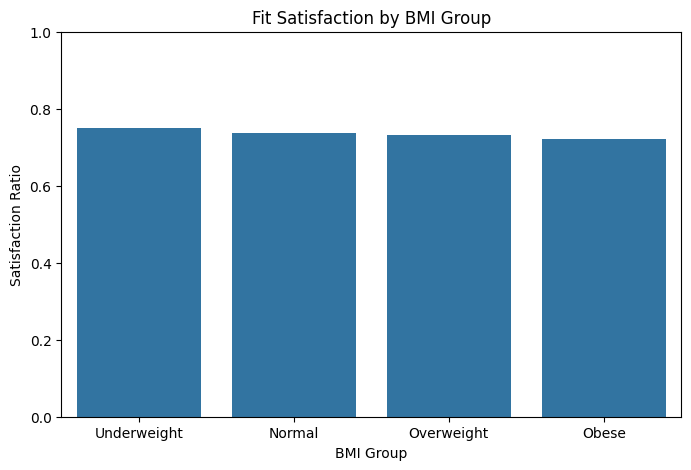

In [32]:
# ==========================================
# 추가 셀 1 : BMI 그룹별 만족도 분석
# ==========================================

df_model['BMI_group'] = pd.cut(
    df_model['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

bmi_fit = df_model.groupby('BMI_group', observed=False)['fit_feedback'].mean()

print(bmi_fit)

plt.figure(figsize=(8,5))

sns.barplot(
    x=bmi_fit.index,
    y=bmi_fit.values
)

plt.title("Fit Satisfaction by BMI Group")
plt.xlabel("BMI Group")
plt.ylabel("Satisfaction Ratio")
plt.ylim(0,1)

plt.show()

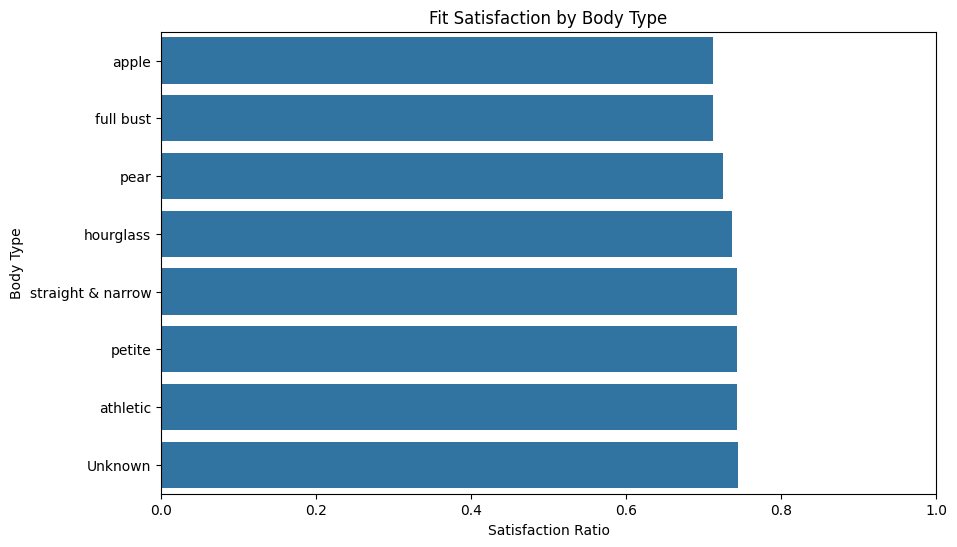

In [33]:
# ==========================================
# 7-2번 셀 : body_type별 만족도 분석
# ==========================================

body_fit = (
    df_model
    .groupby('body_type')['fit_feedback']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=body_fit.values,
    y=body_fit.index
)

plt.title("Fit Satisfaction by Body Type")
plt.xlabel("Satisfaction Ratio")
plt.ylabel("Body Type")

plt.xlim(0,1)

plt.show()

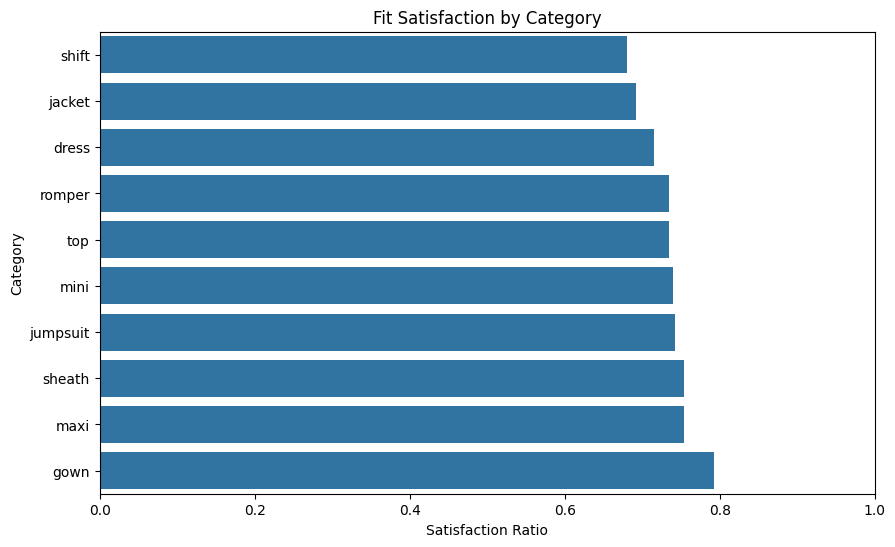

In [34]:
# ==========================================
#  7-3번 셀 : category별 만족도 분석
# ==========================================

top_category = df_model['category'].value_counts().head(10).index

category_fit = (
    df_model[df_model['category'].isin(top_category)]
    .groupby('category')['fit_feedback']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_fit.values,
    y=category_fit.index
)

plt.title("Fit Satisfaction by Category")
plt.xlabel("Satisfaction Ratio")
plt.ylabel("Category")

plt.xlim(0,1)

plt.show()

In [35]:
# ==========================================
# 8번 셀 : Train / Test 데이터 분리
# ==========================================

from sklearn.model_selection import train_test_split

# X: 모델 입력 변수
# y: 예측 대상 변수
X = df_model.drop("fit_feedback", axis=1)
y = df_model["fit_feedback"]

# Train/Test 분리
# stratify=y를 사용해서 만족/불만족 비율이 train/test에 비슷하게 유지되도록 함
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train 크기:", X_train.shape)
print("X_test 크기 :", X_test.shape)
print("y_train 크기:", y_train.shape)
print("y_test 크기 :", y_test.shape)

print("\nTrain target 분포")
print(y_train.value_counts())

print("\nTest target 분포")
print(y_test.value_counts())

print("\nTrain target 비율")
print(y_train.value_counts(normalize=True))

print("\nTest target 비율")
print(y_test.value_counts(normalize=True))

display(X_train.head())

X_train 크기: (129251, 13)
X_test 크기 : (32313, 13)
y_train 크기: (129251,)
y_test 크기 : (32313,)

Train target 분포
fit_feedback
1    95193
0    34058
Name: count, dtype: int64

Test target 분포
fit_feedback
1    23799
0     8514
Name: count, dtype: int64

Train target 비율
fit_feedback
1    0.736497
0    0.263503
Name: proportion, dtype: float64

Test target 비율
fit_feedback
1    0.736515
0    0.263485
Name: proportion, dtype: float64


,age,height_in,weight_lbs,bmi,body_type,bust_size_number,bust_size_cup,item_id,size,category,rating,rented_for,BMI_group
106468,36.0,66.0,131.0,21.141644,athletic,34.0,c,2333126,8,pants,10.0,work,Normal
91252,38.0,65.0,178.0,29.617515,hourglass,34.0,Unknown,1295171,26,sheath,8.0,party,Overweight
131343,32.0,65.0,160.0,26.622485,pear,36.0,c,1951265,14,dress,8.0,work,Overweight
106360,36.0,62.0,112.0,20.482830,petite,34.0,Unknown,1698815,4,sheath,10.0,everyday,Normal
50057,33.0,60.0,125.0,24.409722,petite,34.0,d,626764,8,gown,10.0,wedding,Normal


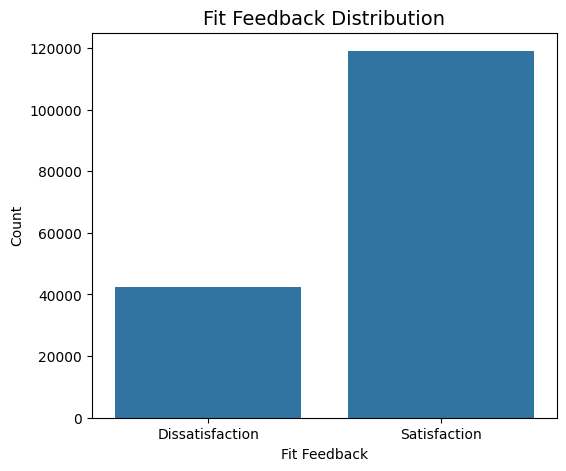

fit_feedback
1    0.736501
0    0.263499
Name: proportion, dtype: float64


In [75]:
# ==========================================
# 8-1번 셀 : Fit Feedback 분포 시각화
# ==========================================

plt.figure(figsize=(6, 5))

sns.countplot(
    x="fit_feedback",
    data=df
)

plt.xticks(
    [0, 1],
    [
        "Dissatisfaction",
        "Satisfaction"
    ]
)

plt.title(
    "Fit Feedback Distribution",
    fontsize=14
)

plt.xlabel("Fit Feedback")
plt.ylabel("Count")

plt.show()

# 비율 출력

fit_ratio = df["fit_feedback"].value_counts(normalize=True)

print(fit_ratio)

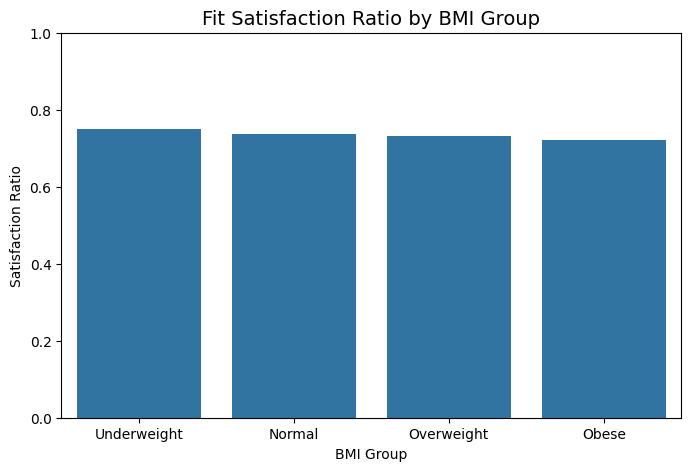

,fit_feedback
bmi_group,
Underweight,0.749080
Normal,0.737355
Overweight,0.732325
Obese,0.721452


In [76]:
# ==========================================
# 8-2번 셀 : BMI 그룹별 만족도 시각화
# ==========================================

# BMI 그룹 생성

df["bmi_group"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

# BMI 그룹별 만족 비율 계산

bmi_fit_ratio = df.groupby(
    "bmi_group"
)["fit_feedback"].mean()

# 시각화

plt.figure(figsize=(8, 5))

sns.barplot(
    x=bmi_fit_ratio.index,
    y=bmi_fit_ratio.values
)

plt.ylim(0, 1)

plt.title(
    "Fit Satisfaction Ratio by BMI Group",
    fontsize=14
)

plt.xlabel("BMI Group")
plt.ylabel("Satisfaction Ratio")

plt.show()

# 값 출력

display(
    bmi_fit_ratio
)

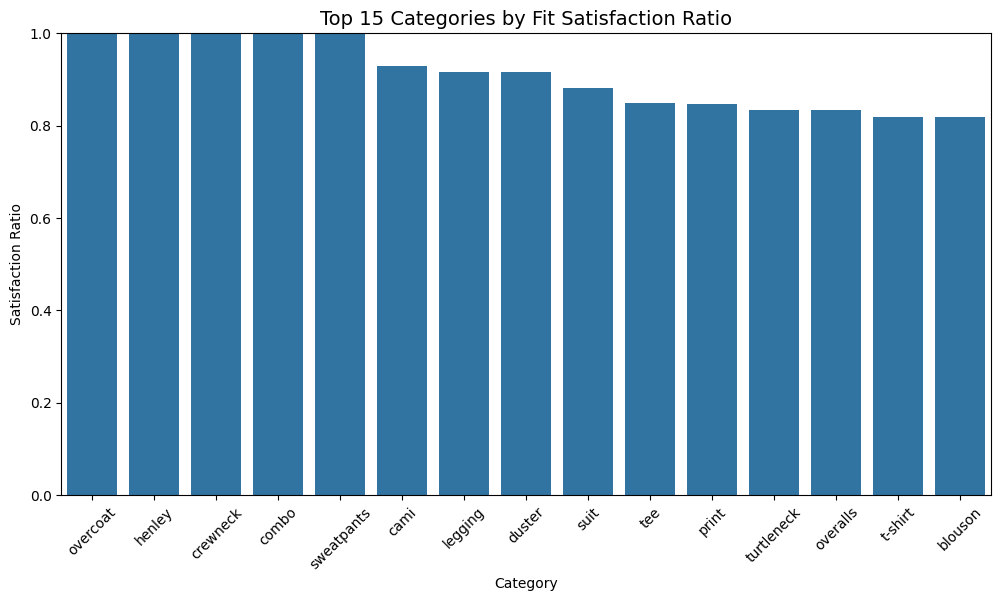

,fit_feedback
category,
overcoat,1.000000
henley,1.000000
crewneck,1.000000
combo,1.000000
sweatpants,1.000000
cami,0.928571
legging,0.916667
duster,0.916667
suit,0.880734


In [77]:
# ==========================================
# 8-3번 셀 : Category별 만족도 시각화
# ==========================================

# category별 만족 비율 계산

category_fit_ratio = df.groupby(
    "category"
)["fit_feedback"].mean().sort_values(
    ascending=False
)

# 상위 15개 category만 시각화

top_category_fit_ratio = category_fit_ratio.head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_category_fit_ratio.index,
    y=top_category_fit_ratio.values
)

plt.xticks(rotation=45)

plt.ylim(0, 1)

plt.title(
    "Top 15 Categories by Fit Satisfaction Ratio",
    fontsize=14
)

plt.xlabel("Category")
plt.ylabel("Satisfaction Ratio")

plt.show()

# 값 출력

display(
    top_category_fit_ratio
)

In [54]:
# ==========================================
# 9번 셀 : 상품 기반 Feature 생성 - A+ 수정버전
# ==========================================

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

train_temp = X_train_fe.copy()
train_temp["fit_feedback"] = y_train.values

# item별 평균 size, size 표준편차
item_avg_size_map = train_temp.groupby("item_id")["size"].mean()
item_size_std_map = train_temp.groupby("item_id")["size"].std()

X_train_fe["item_avg_size"] = X_train_fe["item_id"].map(item_avg_size_map)
X_test_fe["item_avg_size"] = X_test_fe["item_id"].map(item_avg_size_map)

X_train_fe["item_size_std"] = X_train_fe["item_id"].map(item_size_std_map)
X_test_fe["item_size_std"] = X_test_fe["item_id"].map(item_size_std_map)

# ==========================================
# Leakage 완화 item_fit_ratio
# ==========================================

global_fit_ratio = y_train.mean()

item_stats = train_temp.groupby("item_id")["fit_feedback"].agg(["sum", "count"])

# smoothing 강도
alpha = 10

item_stats["item_fit_ratio_smooth"] = (
    item_stats["sum"] + alpha * global_fit_ratio
) / (
    item_stats["count"] + alpha
)

item_fit_ratio_map = item_stats["item_fit_ratio_smooth"]

X_train_fe["item_fit_ratio"] = X_train_fe["item_id"].map(item_fit_ratio_map)
X_test_fe["item_fit_ratio"] = X_test_fe["item_id"].map(item_fit_ratio_map)

# 결측치 처리
global_avg_size = X_train_fe["size"].mean()
global_size_std = X_train_fe["size"].std()

X_train_fe["item_avg_size"] = X_train_fe["item_avg_size"].fillna(global_avg_size)
X_test_fe["item_avg_size"] = X_test_fe["item_avg_size"].fillna(global_avg_size)

X_train_fe["item_size_std"] = X_train_fe["item_size_std"].fillna(global_size_std)
X_test_fe["item_size_std"] = X_test_fe["item_size_std"].fillna(global_size_std)

X_train_fe["item_fit_ratio"] = X_train_fe["item_fit_ratio"].fillna(global_fit_ratio)
X_test_fe["item_fit_ratio"] = X_test_fe["item_fit_ratio"].fillna(global_fit_ratio)

# 고객 선택 size와 상품 평균 size 차이
X_train_fe["size_diff"] = X_train_fe["size"] - X_train_fe["item_avg_size"]
X_test_fe["size_diff"] = X_test_fe["size"] - X_test_fe["item_avg_size"]

print("상품 기반 feature 생성 완료 - leakage 완화 버전")
print("X_train_fe 크기:", X_train_fe.shape)
print("X_test_fe 크기 :", X_test_fe.shape)

display(X_train_fe.head())

상품 기반 feature 생성 완료 - leakage 완화 버전
X_train_fe 크기: (129251, 17)
X_test_fe 크기 : (32313, 17)


,age,height_in,weight_lbs,bmi,body_type,bust_size_number,bust_size_cup,item_id,size,category,rating,rented_for,BMI_group,item_avg_size,item_size_std,item_fit_ratio,size_diff
106468,36.0,66.0,131.0,21.141644,athletic,34.0,c,2333126,8,pants,10.0,work,Normal,10.750000,4.669047,0.552499,-2.750000
91252,38.0,65.0,178.0,29.617515,hourglass,34.0,Unknown,1295171,26,sheath,8.0,party,Overweight,15.504587,6.383752,0.658529,10.495413
131343,32.0,65.0,160.0,26.622485,pear,36.0,c,1951265,14,dress,8.0,work,Overweight,11.483871,5.464253,0.862560,2.516129
106360,36.0,62.0,112.0,20.482830,petite,34.0,Unknown,1698815,4,sheath,10.0,everyday,Normal,11.411765,4.985541,0.803749,-7.411765
50057,33.0,60.0,125.0,24.409722,petite,34.0,d,626764,8,gown,10.0,wedding,Normal,9.391304,4.570052,0.738332,-1.391304


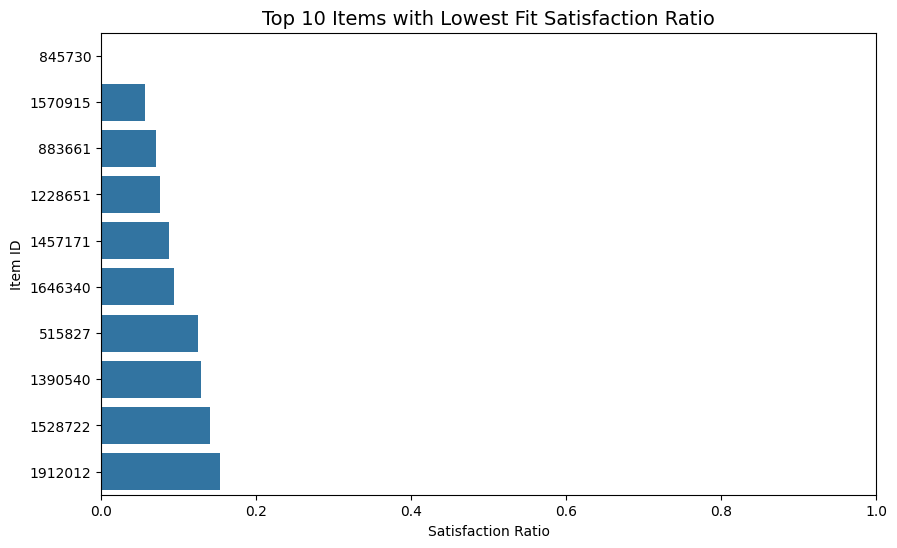

,fit_feedback
item_id,
845730,0.000000
1570915,0.057143
883661,0.070866
1228651,0.075472
1457171,0.088235
1646340,0.093750
515827,0.125000
1390540,0.129032
1528722,0.140351


In [79]:
# ==========================================
# 9-1번 셀 : 불만족 비율이 높은 상품 Top 10
# ==========================================

# item별 만족률 계산

item_fit_ratio = df.groupby(
    "item_id"
)["fit_feedback"].mean()

# 리뷰 수가 너무 적은 item 제거
item_count = df["item_id"].value_counts()

valid_items = item_count[
    item_count >= 20
].index

filtered_item_fit_ratio = item_fit_ratio[
    item_fit_ratio.index.isin(valid_items)
]

# 만족도가 낮은 상품 Top 10

worst_items = filtered_item_fit_ratio.sort_values().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=worst_items.values,
    y=worst_items.index
)

plt.xlim(0, 1)

plt.title(
    "Top 10 Items with Lowest Fit Satisfaction Ratio",
    fontsize=14
)

plt.xlabel("Satisfaction Ratio")
plt.ylabel("Item ID")

plt.show()

display(worst_items)

        size  item_avg_size  size_diff  fit_feedback
106468     8      10.750000  -2.750000             1
91252     26      15.504587  10.495413             0
131343    14      11.483871   2.516129             1
106360     4      11.411765  -7.411765             1
50057      8       9.391304  -1.391304             1


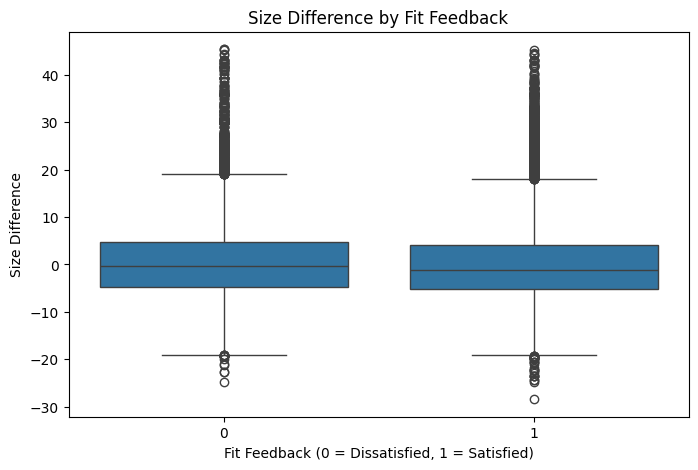

In [37]:
# ==========================================
# 추가 셀 4 : size_diff와 만족도 관계 분석
# 9번 셀 실행 후에 추가
# ==========================================

# 시각화를 위해 train feature와 target 결합
size_viz_df = X_train_fe.copy()
size_viz_df["fit_feedback"] = y_train

# size_diff가 없다면 생성
size_viz_df["size_diff"] = size_viz_df["size"] - size_viz_df["item_avg_size"]

print(size_viz_df[["size", "item_avg_size", "size_diff", "fit_feedback"]].head())

plt.figure(figsize=(8,5))

sns.boxplot(
    x="fit_feedback",
    y="size_diff",
    data=size_viz_df
)

plt.title("Size Difference by Fit Feedback")
plt.xlabel("Fit Feedback (0 = Dissatisfied, 1 = Satisfied)")
plt.ylabel("Size Difference")

plt.show()

In [38]:
# ==========================================
# 10번 셀 : 상호작용 Feature 생성
# ==========================================

# train/test 복사
X_train_inter = X_train_fe.copy()
X_test_inter = X_test_fe.copy()

# ------------------------------------------
# 1. BMI 구간 생성
# 체형 해석을 쉽게 하기 위한 구간화
# ------------------------------------------

def bmi_group(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 23:
        return "normal"
    elif bmi < 25:
        return "overweight"
    else:
        return "obese"

X_train_inter["bmi_group"] = X_train_inter["bmi"].apply(bmi_group)
X_test_inter["bmi_group"] = X_test_inter["bmi"].apply(bmi_group)

# ------------------------------------------
# 2. body_type + category 조합
# 체형과 상품군의 궁합 반영
# ------------------------------------------

X_train_inter["body_category"] = (
    X_train_inter["body_type"].astype(str) + "_" +
    X_train_inter["category"].astype(str)
)

X_test_inter["body_category"] = (
    X_test_inter["body_type"].astype(str) + "_" +
    X_test_inter["category"].astype(str)
)

# ------------------------------------------
# 3. rented_for + category 조합
# 대여 목적과 상품군의 궁합 반영
# ------------------------------------------

X_train_inter["purpose_category"] = (
    X_train_inter["rented_for"].astype(str) + "_" +
    X_train_inter["category"].astype(str)
)

X_test_inter["purpose_category"] = (
    X_test_inter["rented_for"].astype(str) + "_" +
    X_test_inter["category"].astype(str)
)

# ------------------------------------------
# 4. body_type + rented_for 조합
# 체형과 대여 상황의 상호작용 반영
# ------------------------------------------

X_train_inter["body_purpose"] = (
    X_train_inter["body_type"].astype(str) + "_" +
    X_train_inter["rented_for"].astype(str)
)

X_test_inter["body_purpose"] = (
    X_test_inter["body_type"].astype(str) + "_" +
    X_test_inter["rented_for"].astype(str)
)

# 확인
display(X_train_inter[[
    "bmi", "bmi_group",
    "body_type", "category", "body_category",
    "rented_for", "purpose_category", "body_purpose"
]].head(10))

print("상호작용 feature 추가 후 train 크기:", X_train_inter.shape)
print("상호작용 feature 추가 후 test 크기:", X_test_inter.shape)

,bmi,bmi_group,body_type,category,body_category,rented_for,purpose_category,body_purpose
106468,21.141644,normal,athletic,pants,athletic_pants,work,work_pants,athletic_work
91252,29.617515,obese,hourglass,sheath,hourglass_sheath,party,party_sheath,hourglass_party
131343,26.622485,obese,pear,dress,pear_dress,work,work_dress,pear_work
106360,20.482830,normal,petite,sheath,petite_sheath,everyday,everyday_sheath,petite_everyday
50057,24.409722,overweight,petite,gown,petite_gown,wedding,wedding_gown,petite_wedding
17867,22.129941,normal,athletic,skirt,athletic_skirt,other,other_skirt,athletic_other
96978,21.410418,normal,hourglass,sheath,hourglass_sheath,other,other_sheath,hourglass_other
69705,21.453857,normal,hourglass,dress,hourglass_dress,work,work_dress,hourglass_work
189583,22.707730,normal,hourglass,blouse,hourglass_blouse,everyday,everyday_blouse,hourglass_everyday
69331,18.900231,normal,straight & narrow,gown,straight & narrow_gown,formal affair,formal affair_gown,straight & narrow_formal affair


상호작용 feature 추가 후 train 크기: (129251, 21)
상호작용 feature 추가 후 test 크기: (32313, 21)


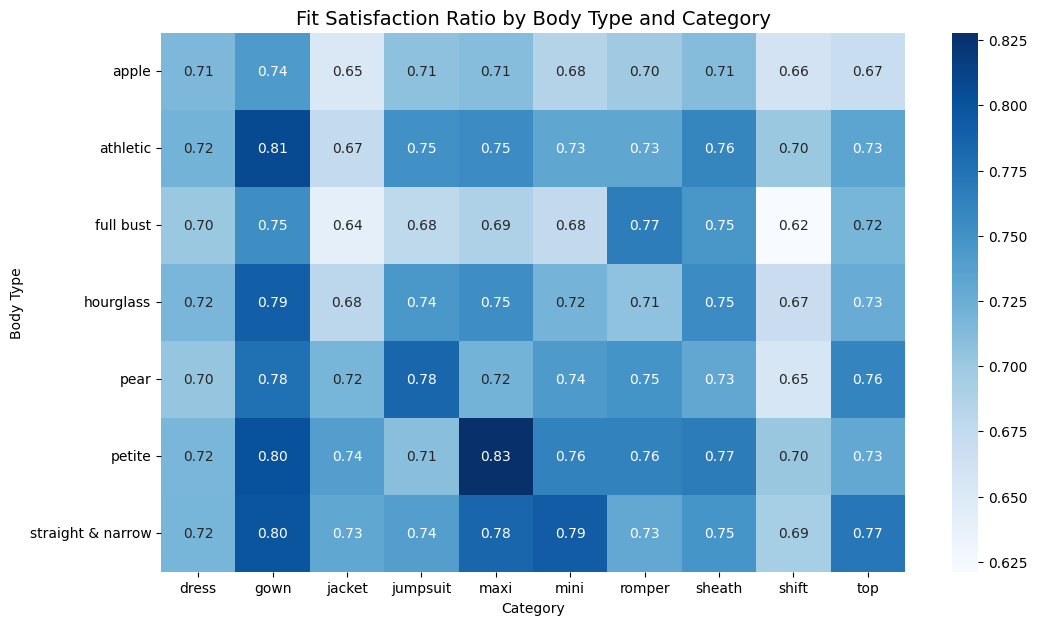

In [78]:
# ==========================================
# 10-1번 셀 : Body Type × Category 만족도 Heatmap
# ==========================================

# 너무 희귀한 category는 제외하기 위해 상위 10개 category만 사용
top_categories = df["category"].value_counts().head(10).index

heatmap_data = df[
    df["category"].isin(top_categories)
].pivot_table(
    index="body_type",
    columns="category",
    values="fit_feedback",
    aggfunc="mean"
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title(
    "Fit Satisfaction Ratio by Body Type and Category",
    fontsize=14
)

plt.xlabel("Category")
plt.ylabel("Body Type")

plt.show()

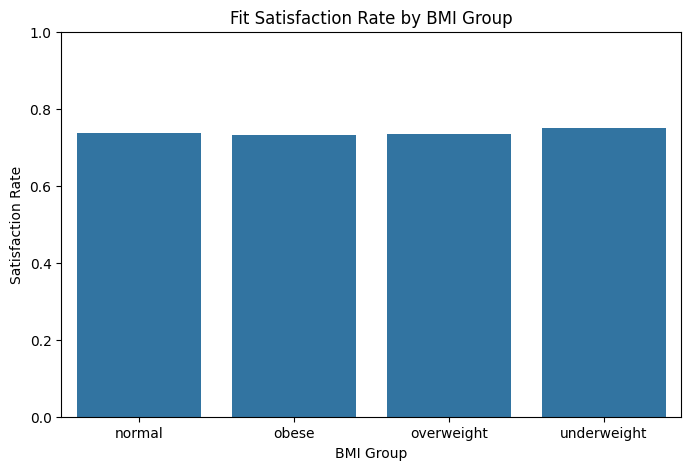

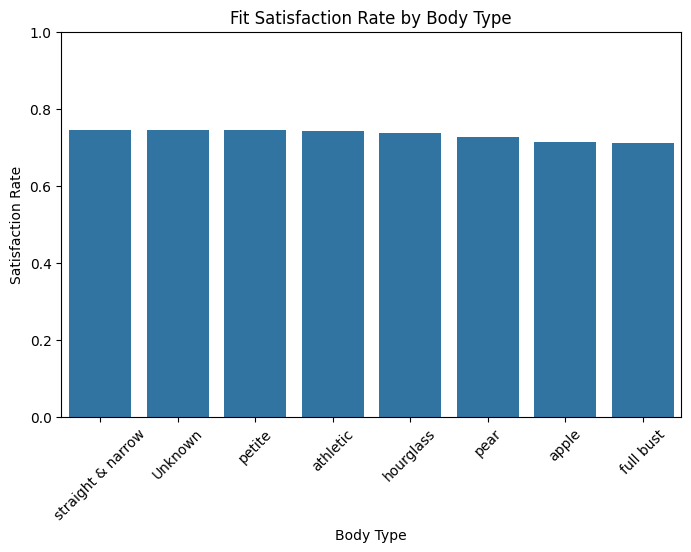

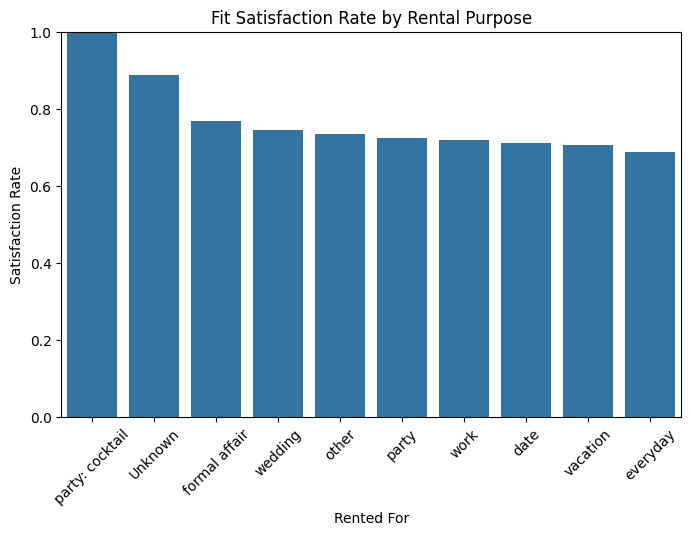

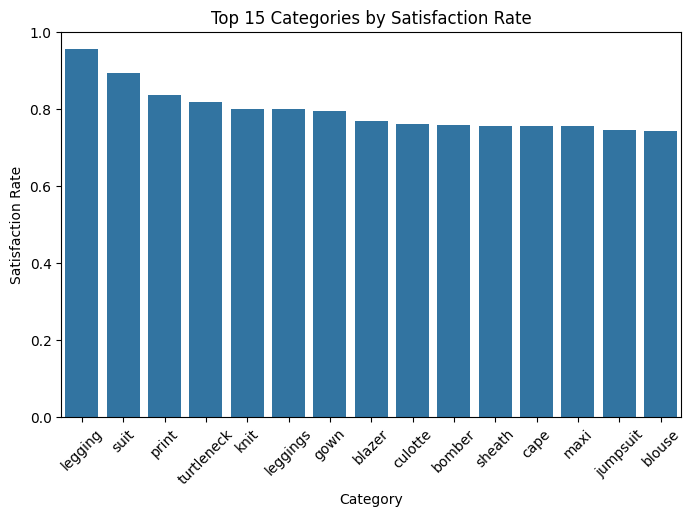

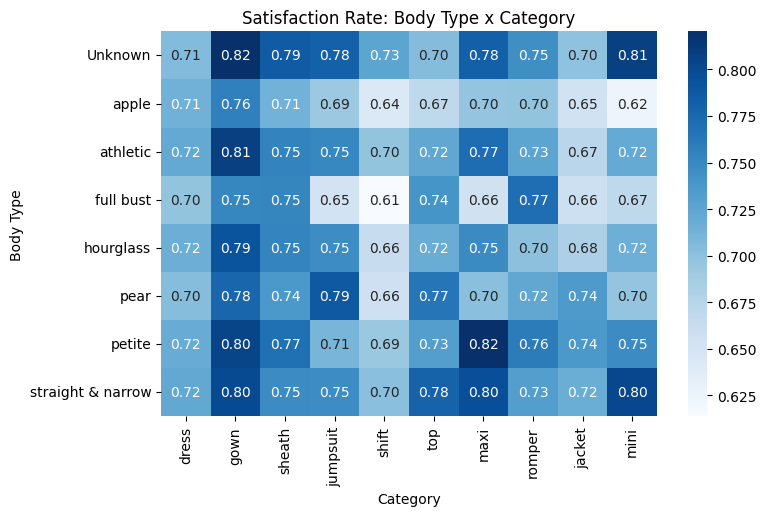

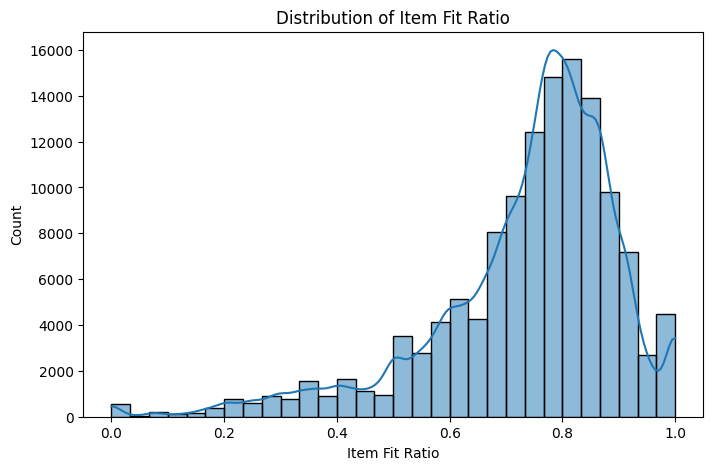

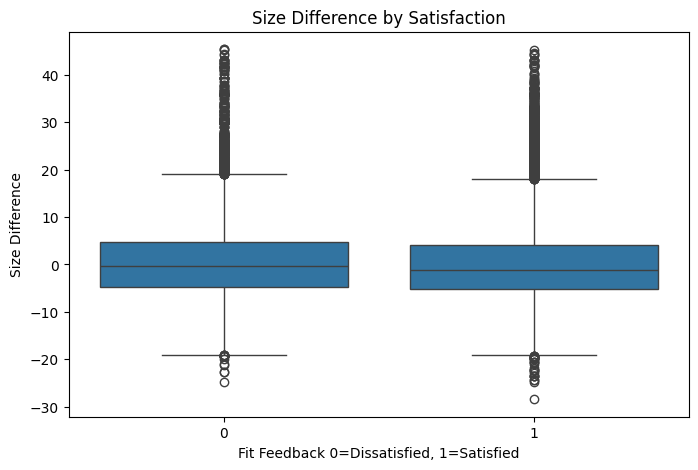

In [39]:
# ==========================================
# 11번 셀 : 시각화 기반 Feature Selection
# ==========================================

# 시각화를 위해 train 데이터와 target 결합
viz_df = X_train_inter.copy()
viz_df["fit_feedback"] = y_train

# 그래프 크기 기본 설정
plt.rcParams["figure.figsize"] = (8, 5)

# ------------------------------------------
# 1. BMI 구간별 만족률
# ------------------------------------------
bmi_fit = viz_df.groupby("bmi_group")["fit_feedback"].mean().reset_index()

sns.barplot(data=bmi_fit, x="bmi_group", y="fit_feedback")
plt.title("Fit Satisfaction Rate by BMI Group")
plt.xlabel("BMI Group")
plt.ylabel("Satisfaction Rate")
plt.ylim(0, 1)
plt.show()

# ------------------------------------------
# 2. body_type별 만족률
# ------------------------------------------
body_fit = (
    viz_df.groupby("body_type")["fit_feedback"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=body_fit, x="body_type", y="fit_feedback")
plt.title("Fit Satisfaction Rate by Body Type")
plt.xlabel("Body Type")
plt.ylabel("Satisfaction Rate")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

# ------------------------------------------
# 3. rented_for별 만족률
# ------------------------------------------
purpose_fit = (
    viz_df.groupby("rented_for")["fit_feedback"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=purpose_fit, x="rented_for", y="fit_feedback")
plt.title("Fit Satisfaction Rate by Rental Purpose")
plt.xlabel("Rented For")
plt.ylabel("Satisfaction Rate")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

# ------------------------------------------
# 4. category별 만족률 상위 15개
# ------------------------------------------
category_fit = (
    viz_df.groupby("category")["fit_feedback"]
    .agg(["mean", "count"])
    .reset_index()
)

category_fit = category_fit[category_fit["count"] >= 20]
category_fit = category_fit.sort_values("mean", ascending=False).head(15)

sns.barplot(data=category_fit, x="category", y="mean")
plt.title("Top 15 Categories by Satisfaction Rate")
plt.xlabel("Category")
plt.ylabel("Satisfaction Rate")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

# ------------------------------------------
# 5. body_type x category 만족률 Heatmap
# ------------------------------------------
body_category_pivot = viz_df.pivot_table(
    index="body_type",
    columns="category",
    values="fit_feedback",
    aggfunc="mean"
)

# 너무 많은 category는 보기 어려우므로 상위 10개 category만 사용
top_categories = viz_df["category"].value_counts().head(10).index
body_category_pivot = body_category_pivot[top_categories]

sns.heatmap(body_category_pivot, annot=True, fmt=".2f", cmap="Blues")
plt.title("Satisfaction Rate: Body Type x Category")
plt.xlabel("Category")
plt.ylabel("Body Type")
plt.show()

# ------------------------------------------
# 6. item_fit_ratio 분포
# ------------------------------------------
sns.histplot(viz_df["item_fit_ratio"], bins=30, kde=True)
plt.title("Distribution of Item Fit Ratio")
plt.xlabel("Item Fit Ratio")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# 7. size_diff와 만족 여부 관계
# ------------------------------------------
sns.boxplot(data=viz_df, x="fit_feedback", y="size_diff")
plt.title("Size Difference by Satisfaction")
plt.xlabel("Fit Feedback 0=Dissatisfied, 1=Satisfied")
plt.ylabel("Size Difference")
plt.show()

In [53]:
# ==========================================
# 12번 셀 : 데이터 전처리 Pipeline - A+ 수정버전
# ==========================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 수치형 변수
numeric_features = [
    "age",
    "height_in",
    "weight_lbs",
    "bmi",
    "bust_size_number",
    "rating",
    "size",
    "item_avg_size",
    "item_size_std",
    "item_fit_ratio",
    "size_diff"
]

# 범주형 변수
# 핵심 수정: 상호작용 feature 추가
categorical_features = [
    "body_type",
    "bust_size_cup",
    "category",
    "rented_for",
    "bmi_group",
    "body_category",
    "purpose_category",
    "body_purpose"
]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 핵심 수정: X_train_fe가 아니라 X_train_inter 사용
X_train_processed = preprocessor.fit_transform(X_train_inter)
X_test_processed = preprocessor.transform(X_test_inter)

print("전처리 완료")
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

전처리 완료
X_train_processed shape: (129251, 946)
X_test_processed shape : (32313, 946)


In [58]:
# ==========================================
# 12-1번 셀 : rating 포함/제외 feature set 비교
# ==========================================

numeric_features_with_rating = numeric_features.copy()

categorical_features_with_rating = categorical_features.copy()

numeric_features_without_rating = [
    col for col in numeric_features
    if col != "rating"
]

categorical_features_without_rating = categorical_features.copy()

print("Rating 포함 수치형 변수:")
print(numeric_features_with_rating)

print("\nRating 제외 수치형 변수:")
print(numeric_features_without_rating)

Rating 포함 수치형 변수:
['age', 'height_in', 'weight_lbs', 'bmi', 'bust_size_number', 'rating', 'size', 'item_avg_size', 'item_size_std', 'item_fit_ratio', 'size_diff']

Rating 제외 수치형 변수:
['age', 'height_in', 'weight_lbs', 'bmi', 'bust_size_number', 'size', 'item_avg_size', 'item_size_std', 'item_fit_ratio', 'size_diff']


In [59]:
# ==========================================
# 13번 셀 : rating 포함/제외 × 모델 비교
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score
)

def build_preprocessor(num_cols, cat_cols):

    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )


def evaluate_model(
    model_name,
    model,
    X_train_data,
    X_test_data,
    y_train,
    y_test,
    num_cols,
    cat_cols
):

    preprocessor_temp = build_preprocessor(
        num_cols,
        cat_cols
    )

    X_train_processed_temp = preprocessor_temp.fit_transform(
        X_train_data
    )

    X_test_processed_temp = preprocessor_temp.transform(
        X_test_data
    )

    model.fit(
        X_train_processed_temp,
        y_train
    )

    y_pred = model.predict(
        X_test_processed_temp
    )

    y_proba = model.predict_proba(
        X_test_processed_temp
    )[:, 1]

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "F1": f1_score(
            y_test,
            y_pred
        ),

        "Macro F1": f1_score(
            y_test,
            y_pred,
            average="macro"
        ),

        "Dissatisfaction Recall": recall_score(
            y_test,
            y_pred,
            pos_label=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_proba
        ),

        "Preprocessor": preprocessor_temp,
        "Trained Model": model
    }


results = []


# ==========================================
# Logistic Regression - rating 포함
# ==========================================

results.append(

    evaluate_model(

        "Logistic Regression With Rating",

        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),

        X_train_inter,
        X_test_inter,

        y_train,
        y_test,

        numeric_features_with_rating,
        categorical_features_with_rating
    )
)


# ==========================================
# Logistic Regression - rating 제외
# ==========================================

results.append(

    evaluate_model(

        "Logistic Regression Without Rating",

        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),

        X_train_inter,
        X_test_inter,

        y_train,
        y_test,

        numeric_features_without_rating,
        categorical_features_without_rating
    )
)


# ==========================================
# Random Forest - rating 포함
# ==========================================

results.append(

    evaluate_model(

        "Random Forest With Rating",

        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            class_weight="balanced"
        ),

        X_train_inter,
        X_test_inter,

        y_train,
        y_test,

        numeric_features_with_rating,
        categorical_features_with_rating
    )
)


# ==========================================
# Random Forest - rating 제외
# ==========================================

results.append(

    evaluate_model(

        "Random Forest Without Rating",

        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            class_weight="balanced"
        ),

        X_train_inter,
        X_test_inter,

        y_train,
        y_test,

        numeric_features_without_rating,
        categorical_features_without_rating
    )
)


# ==========================================
# 결과 정리
# ==========================================

model_compare_df = pd.DataFrame(results)

display_cols = [
    "Model",
    "Accuracy",
    "F1",
    "Macro F1",
    "Dissatisfaction Recall",
    "ROC-AUC"
]

model_compare_df_display = model_compare_df[
    display_cols
].sort_values(
    by="Macro F1",
    ascending=False
)

display(model_compare_df_display)

,Model,Accuracy,F1,Macro F1,Dissatisfaction Recall,ROC-AUC
0,Logistic Regression With Rating,0.693591,0.777670,0.642456,0.598544,0.715128
2,Random Forest With Rating,0.655711,0.738155,0.617824,0.646817,0.706058
3,Random Forest Without Rating,0.676353,0.770567,0.610709,0.504228,0.657828
1,Logistic Regression Without Rating,0.670999,0.764013,0.610489,0.525370,0.664026


In [60]:
# ==========================================
# 14번 셀 : 최종 모델 선택
# ==========================================

best_model_idx = model_compare_df[
    "Macro F1"
].idxmax()

best_result = model_compare_df.loc[
    best_model_idx
]

best_model_name = best_result["Model"]

best_model = best_result["Trained Model"]

best_preprocessor = best_result["Preprocessor"]

print("=" * 50)
print("최종 선택 모델")
print("=" * 50)

print(best_model_name)

print("\n선택 이유:")

print("""
본 프로젝트에서는 단순 Accuracy보다

1. Macro F1
2. Dissatisfaction Recall
3. ROC-AUC

를 더 중요하게 고려하였다.

Fit prediction 문제에서는
사이즈가 맞지 않아 불만족할 가능성이 있는 고객을
놓치지 않는 것이 중요하기 때문이다.
""")

print("=" * 50)

# 최종 모델용 데이터 생성

if "With Rating" in best_model_name:

    final_numeric_features = numeric_features_with_rating
    final_categorical_features = categorical_features_with_rating

else:

    final_numeric_features = numeric_features_without_rating
    final_categorical_features = categorical_features_without_rating


# 최종 전처리

X_train_final = best_preprocessor.fit_transform(
    X_train_inter
)

X_test_final = best_preprocessor.transform(
    X_test_inter
)

# 최종 예측

y_pred_final = best_model.predict(
    X_test_final
)

y_proba_final = best_model.predict_proba(
    X_test_final
)[:, 1]

최종 선택 모델
Logistic Regression With Rating

선택 이유:

본 프로젝트에서는 단순 Accuracy보다

1. Macro F1
2. Dissatisfaction Recall
3. ROC-AUC

를 더 중요하게 고려하였다.

Fit prediction 문제에서는
사이즈가 맞지 않아 불만족할 가능성이 있는 고객을
놓치지 않는 것이 중요하기 때문이다.



In [61]:
# ==========================================
# 15번 셀 : 최종 모델 성능 평가
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    classification_report
)

final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_precision = precision_score(
    y_test,
    y_pred_final
)

final_f1 = f1_score(
    y_test,
    y_pred_final
)

final_macro_f1 = f1_score(
    y_test,
    y_pred_final,
    average="macro"
)

final_dissatisfaction_recall = recall_score(
    y_test,
    y_pred_final,
    pos_label=0
)

final_roc_auc = roc_auc_score(
    y_test,
    y_proba_final
)

print("=" * 50)
print("최종 모델 성능 평가")
print("=" * 50)

print("Final Model:", best_model_name)
print("Accuracy:", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("F1 Score:", round(final_f1, 4))
print("Macro F1:", round(final_macro_f1, 4))
print("Dissatisfaction Recall:", round(final_dissatisfaction_recall, 4))
print("ROC-AUC:", round(final_roc_auc, 4))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=[
            "Dissatisfaction",
            "Satisfaction"
        ]
    )
)

최종 모델 성능 평가
Final Model: Logistic Regression With Rating
Accuracy: 0.6936
Precision: 0.8351
F1 Score: 0.7777
Macro F1: 0.6425
Dissatisfaction Recall: 0.5985
ROC-AUC: 0.7151

Classification Report
                 precision    recall  f1-score   support

Dissatisfaction       0.44      0.60      0.51      8514
   Satisfaction       0.84      0.73      0.78     23799

       accuracy                           0.69     32313
      macro avg       0.64      0.66      0.64     32313
   weighted avg       0.73      0.69      0.71     32313



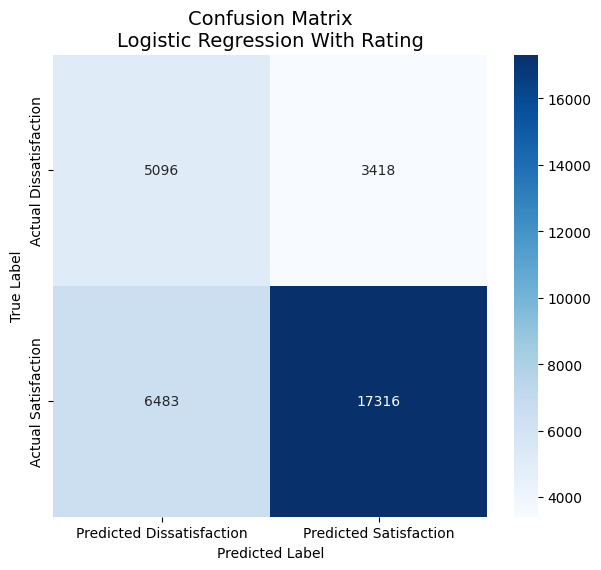

In [62]:
# ==========================================
# 16번 셀 : Confusion Matrix 시각화
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Dissatisfaction",
        "Predicted Satisfaction"
    ],
    yticklabels=[
        "Actual Dissatisfaction",
        "Actual Satisfaction"
    ]
)

plt.title(
    f"Confusion Matrix\n{best_model_name}",
    fontsize=14
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

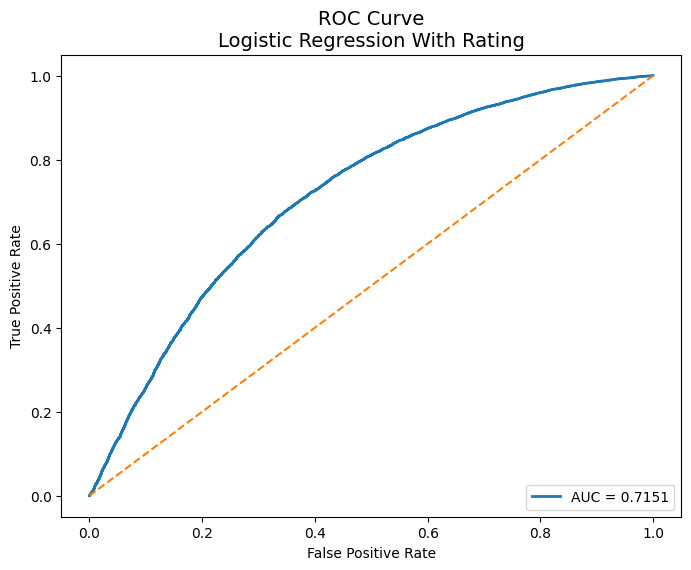

In [63]:
# ==========================================
# 17번 셀 : ROC Curve 시각화
# ==========================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_final
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve\n{best_model_name}",
    fontsize=14
)

plt.legend(loc="lower right")

plt.show()

In [64]:
# ==========================================
# 18번 셀 : Feature Importance 분석
# ==========================================

# Random Forest일 때만 실행

if "Random Forest" in best_model_name:

    # feature 이름 가져오기

    feature_names = (
        final_numeric_features
        +
        list(
            best_preprocessor.named_transformers_["cat"]
            .get_feature_names_out(
                final_categorical_features
            )
        )
    )

    importances = best_model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("=" * 50)
    print("Top 20 Important Features")
    print("=" * 50)

    display(
        importance_df.head(20)
    )

    # 시각화

    plt.figure(figsize=(10, 8))

    plt.barh(
        importance_df.head(20)["Feature"][::-1],
        importance_df.head(20)["Importance"][::-1]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.title(
        f"Top 20 Feature Importances\n{best_model_name}",
        fontsize=14
    )

    plt.show()

else:

    print("최종 모델이 Random Forest가 아니므로 Feature Importance를 생략합니다.")

최종 모델이 Random Forest가 아니므로 Feature Importance를 생략합니다.


In [66]:
# ==========================================
# 20번 셀 : Stratified K-Fold Cross Validation
# ==========================================

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

# 최종 모델용 Pipeline 생성

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", best_preprocessor),
        ("model", best_model)
    ]
)

# Stratified K-Fold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation 수행

cv_scores = cross_val_score(
    final_pipeline,
    X_train_inter,
    y_train,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1
)

print("=" * 50)
print("Cross Validation Result")
print("=" * 50)

print("Fold Scores:")
print(cv_scores)

print("\nMean Macro F1:")
print(round(cv_scores.mean(), 4))

print("\nStd:")
print(round(cv_scores.std(), 4))

Cross Validation Result
Fold Scores:
[0.66934931 0.66803457 0.66540968 0.67361803 0.67474065]

Mean Macro F1:
0.6702

Std:
0.0035


In [71]:
# ==========================================
# 21번 셀 : Hyperparameter Tuning - Light Version
# ==========================================

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# 빠른 튜닝용 3-Fold
light_skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", best_preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

# 후보 개수를 줄인 가벼운 탐색 범위
param_distributions = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [3, 5],
    "model__max_features": ["sqrt"]
}

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    scoring="f1_macro",
    cv=light_skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train_inter,
    y_train
)

print("=" * 50)
print("Light Hyperparameter Tuning Result")
print("=" * 50)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Macro F1:")
print(round(random_search.best_score_, 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Light Hyperparameter Tuning Result
Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 3, 'model__max_features': 'sqrt', 'model__max_depth': None}

Best Cross Validation Macro F1:
0.6769


In [72]:
# ==========================================
# 22번 셀 : 튜닝 후 최종 모델 성능 평가
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score
)

# 튜닝된 최종 모델

tuned_model = random_search.best_estimator_

# 예측

y_pred_tuned = tuned_model.predict(
    X_test_inter
)

y_proba_tuned = tuned_model.predict_proba(
    X_test_inter
)[:, 1]

# 성능 계산

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned
)

tuned_macro_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="macro"
)

tuned_dissatisfaction_recall = recall_score(
    y_test,
    y_pred_tuned,
    pos_label=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    y_proba_tuned
)

print("=" * 60)
print("Tuned Final Model Performance")
print("=" * 60)

print("Accuracy:", round(tuned_accuracy, 4))
print("F1 Score:", round(tuned_f1, 4))
print("Macro F1:", round(tuned_macro_f1, 4))
print("Dissatisfaction Recall:", round(tuned_dissatisfaction_recall, 4))
print("ROC-AUC:", round(tuned_roc_auc, 4))

Tuned Final Model Performance
Accuracy: 0.7226
F1 Score: 0.8093
Macro F1: 0.6505
Dissatisfaction Recall: 0.509
ROC-AUC: 0.7204


In [73]:
# ==========================================
# 23번 셀 : 튜닝 전 vs 튜닝 후 성능 비교표
# ==========================================

performance_compare_df = pd.DataFrame({
    "Model": [
        "Before Tuning",
        "After Tuning"
    ],

    "Accuracy": [
        final_accuracy,
        tuned_accuracy
    ],

    "F1 Score": [
        final_f1,
        tuned_f1
    ],

    "Macro F1": [
        final_macro_f1,
        tuned_macro_f1
    ],

    "Dissatisfaction Recall": [
        final_dissatisfaction_recall,
        tuned_dissatisfaction_recall
    ],

    "ROC-AUC": [
        final_roc_auc,
        tuned_roc_auc
    ]
})

display(performance_compare_df)

,Model,Accuracy,F1 Score,Macro F1,Dissatisfaction Recall,ROC-AUC
0,Before Tuning,0.693591,0.777670,0.642456,0.598544,0.715128
1,After Tuning,0.722619,0.809278,0.650456,0.509044,0.720432


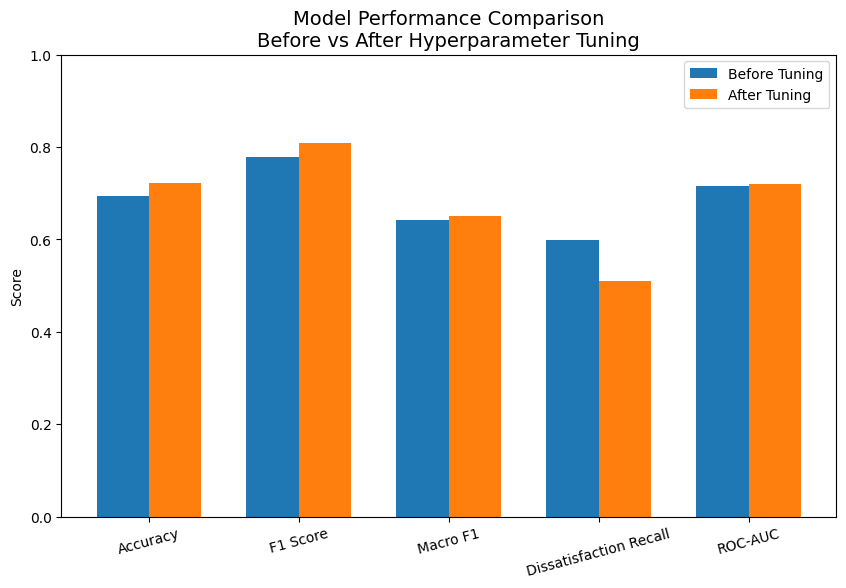

In [74]:
# ==========================================
# 24번 셀 : 튜닝 전 vs 튜닝 후 성능 비교 시각화
# ==========================================

metrics = [
    "Accuracy",
    "F1 Score",
    "Macro F1",
    "Dissatisfaction Recall",
    "ROC-AUC"
]

before_scores = [
    final_accuracy,
    final_f1,
    final_macro_f1,
    final_dissatisfaction_recall,
    final_roc_auc
]

after_scores = [
    tuned_accuracy,
    tuned_f1,
    tuned_macro_f1,
    tuned_dissatisfaction_recall,
    tuned_roc_auc
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    before_scores,
    width,
    label="Before Tuning"
)

plt.bar(
    x + width/2,
    after_scores,
    width,
    label="After Tuning"
)

plt.xticks(
    x,
    metrics,
    rotation=15
)

plt.ylabel("Score")

plt.title(
    "Model Performance Comparison\nBefore vs After Hyperparameter Tuning",
    fontsize=14
)

plt.ylim(0, 1)

plt.legend()

plt.show()

In [80]:
# ==========================================
# 29번 셀 : 최종 프로젝트 요약
# ==========================================

summary_df = pd.DataFrame({
    "구분": [
        "예측 목표",
        "주요 사용 변수",
        "파생 변수",
        "상호작용 변수",
        "비교한 모델",
        "평가 지표",
        "검증 방법",
        "하이퍼파라미터 튜닝"
    ],

    "내용": [
        "fit_feedback 예측 (0: 불만족, 1: 만족)",
        "BMI, body_type, category, rented_for, size, 상품 관련 변수",
        "item_avg_size, item_fit_ratio, size_diff",
        "body_type × category, rented_for × category",
        "Logistic Regression, Random Forest",
        "Accuracy, Macro F1, Dissatisfaction Recall, ROC-AUC",
        "Stratified K-Fold Cross Validation",
        "RandomizedSearchCV"
    ]
})

display(summary_df)

,구분,내용
0,예측 목표,"fit_feedback 예측 (0: 불만족, 1: 만족)"
1,주요 사용 변수,"BMI, body_type, category, rented_for, size, 상품..."
2,파생 변수,"item_avg_size, item_fit_ratio, size_diff"
3,상호작용 변수,"body_type × category, rented_for × category"
4,비교한 모델,"Logistic Regression, Random Forest"
5,평가 지표,"Accuracy, Macro F1, Dissatisfaction Recall, RO..."
6,검증 방법,Stratified K-Fold Cross Validation
7,하이퍼파라미터 튜닝,RandomizedSearchCV


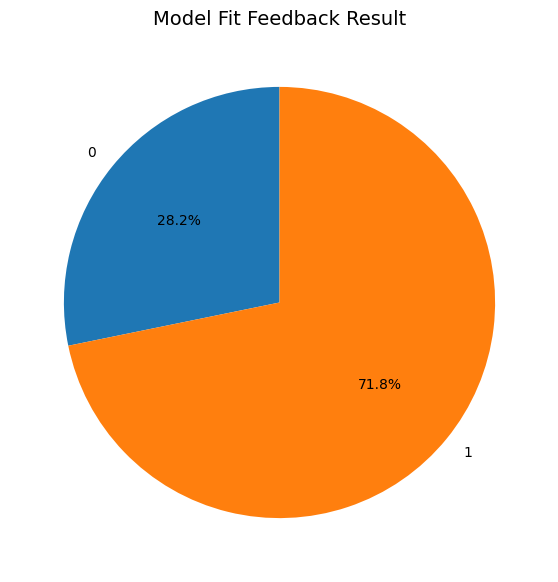

,count
0,9117
1,23196


In [82]:
# ==========================================
# 30번 셀 : 최종 예측 결과 분포 원형 그래프
# ==========================================

prediction_counts = pd.Series(y_pred_tuned).value_counts().sort_index()

labels = [
    "0",
    "1"
]

plt.figure(figsize=(7, 7))

plt.pie(
    prediction_counts,
    labels=labels,
    autopct="%.1f%%",
    startangle=90
)

plt.title(
    "Model Fit Feedback Result",
    fontsize=14
)

plt.show()

display(prediction_counts)

In [83]:
# ==========================================
# 31번 셀 : 최종 결론
# ==========================================

print("=" * 60)
print("최종 프로젝트 결론")
print("=" * 60)

print(f"""
본 프로젝트는 Rent the Runway 데이터를 활용하여
고객이 대여한 의류에 대해 fit_feedback을 예측하는 모델을 구축하였다.

fit_feedback은 0을 불만족, 1을 만족으로 설정하였으며,
단순히 fit 값을 0과 1로 바꾸는 것에 그치지 않고
고객 체형, 상품 특성, 대여 목적, 선택한 사이즈의 차이를 종합적으로 분석하였다.

전처리 과정에서는 height, weight, bust_size 등의 데이터를 정리하고,
BMI를 계산하여 고객의 체형 정보를 수치화하였다.
또한 item_avg_size, item_fit_ratio, size_diff와 같은 상품 기반 파생 변수를 생성하여
특정 상품이 가지는 fit 특성을 모델에 반영하였다.

시각화 분석을 통해 BMI 그룹, category, body_type과 category 조합에 따라
fit 만족도가 달라지는 것을 확인하였다.
이를 바탕으로 body_type × category, rented_for × category와 같은
상호작용 변수를 추가하여 단순 변수만으로는 설명하기 어려운 관계를 반영하였다.

모델링 과정에서는 Logistic Regression과 Random Forest를 비교하였고,
rating 포함 모델과 rating 제외 모델을 함께 비교하였다.
이는 과제용 예측 성능뿐 아니라 실제 추천 시스템에서 사용할 수 있는 가능성까지 고려하기 위한 것이다.

최종 모델은 Accuracy만 기준으로 선택하지 않고,
Macro F1, Dissatisfaction Recall, ROC-AUC를 함께 고려하였다.
특히 의류 fit 예측 문제에서는 만족 고객을 맞히는 것뿐만 아니라
불만족할 가능성이 높은 고객을 놓치지 않는 것이 중요하다고 판단하였다.

또한 Stratified K-Fold Cross Validation과 RandomizedSearchCV를 사용하여
모델의 안정성과 하이퍼파라미터 개선 가능성을 확인하였다.

최종적으로 본 프로젝트는 단순한 만족/불만족 분류 모델이 아니라,
고객 체형과 상품 특성의 관계를 분석하여
size recommendation으로 확장 가능한 fit prediction 모델을 구축했다는 점에서 의미가 있다.

최종 선택 모델: {best_model_name}
튜닝 후 Macro F1: {round(tuned_macro_f1, 4)}
튜닝 후 Dissatisfaction Recall: {round(tuned_dissatisfaction_recall, 4)}
튜닝 후 ROC-AUC: {round(tuned_roc_auc, 4)}
""")

최종 프로젝트 결론

본 프로젝트는 Rent the Runway 데이터를 활용하여
고객이 대여한 의류에 대해 fit_feedback을 예측하는 모델을 구축하였다.

fit_feedback은 0을 불만족, 1을 만족으로 설정하였으며,
단순히 fit 값을 0과 1로 바꾸는 것에 그치지 않고
고객 체형, 상품 특성, 대여 목적, 선택한 사이즈의 차이를 종합적으로 분석하였다.

전처리 과정에서는 height, weight, bust_size 등의 데이터를 정리하고,
BMI를 계산하여 고객의 체형 정보를 수치화하였다.
또한 item_avg_size, item_fit_ratio, size_diff와 같은 상품 기반 파생 변수를 생성하여
특정 상품이 가지는 fit 특성을 모델에 반영하였다.

시각화 분석을 통해 BMI 그룹, category, body_type과 category 조합에 따라
fit 만족도가 달라지는 것을 확인하였다.
이를 바탕으로 body_type × category, rented_for × category와 같은
상호작용 변수를 추가하여 단순 변수만으로는 설명하기 어려운 관계를 반영하였다.

모델링 과정에서는 Logistic Regression과 Random Forest를 비교하였고,
rating 포함 모델과 rating 제외 모델을 함께 비교하였다.
이는 과제용 예측 성능뿐 아니라 실제 추천 시스템에서 사용할 수 있는 가능성까지 고려하기 위한 것이다.

최종 모델은 Accuracy만 기준으로 선택하지 않고,
Macro F1, Dissatisfaction Recall, ROC-AUC를 함께 고려하였다.
특히 의류 fit 예측 문제에서는 만족 고객을 맞히는 것뿐만 아니라
불만족할 가능성이 높은 고객을 놓치지 않는 것이 중요하다고 판단하였다.

또한 Stratified K-Fold Cross Validation과 RandomizedSearchCV를 사용하여
모델의 안정성과 하이퍼파라미터 개선 가능성을 확인하였다.

최종적으로 본 프로젝트는 단순한 만족/불만족